# Result sweeps (boxes × model families)

Loads evaluation JSONs under `output/boxes{n}_exp2_max3_nops12_zero_shot/` with **grouped bars** for accuracy vs **numops** (bins 0–5).

- **`op_types`:** `any` uses saved `by_numops`; `no_move` / `move_only` filter per-row `numops_by_op` and recompute bins (requires `rows` in the JSON).
  - **`no_move`:** `move` count is 0 for the queried box.
  - **`move_only`:** only moves affected the box (`move ≥ 1`, `put = 0`, `remove = 0`).

`load_eval_json()` / `plot_numops_pair_axes()` accept **absolute** paths to single result files under the same folder layout.

**Colors:** grouped bars — **green** = transformer baseline (e.g. Olmo-3, Qwen3-8B/32B); **pink** = hybrid (**Olmo-Hybrid**, **Qwen3.5**), chosen from the filename.

## Trend across `n_boxes`

Call `plot_n_boxes_numops_trend_figure(op_types="any")` — **x** = `n_boxes` in **2…6** (default), **two lines** per subplot (one per model): **overall** set accuracy pooled across all numops. Same ``op_types`` as the bar chart (recomputes from ``rows`` when not `any`).

Implementation: ``src/visualize_helpers.py`` (imported below).


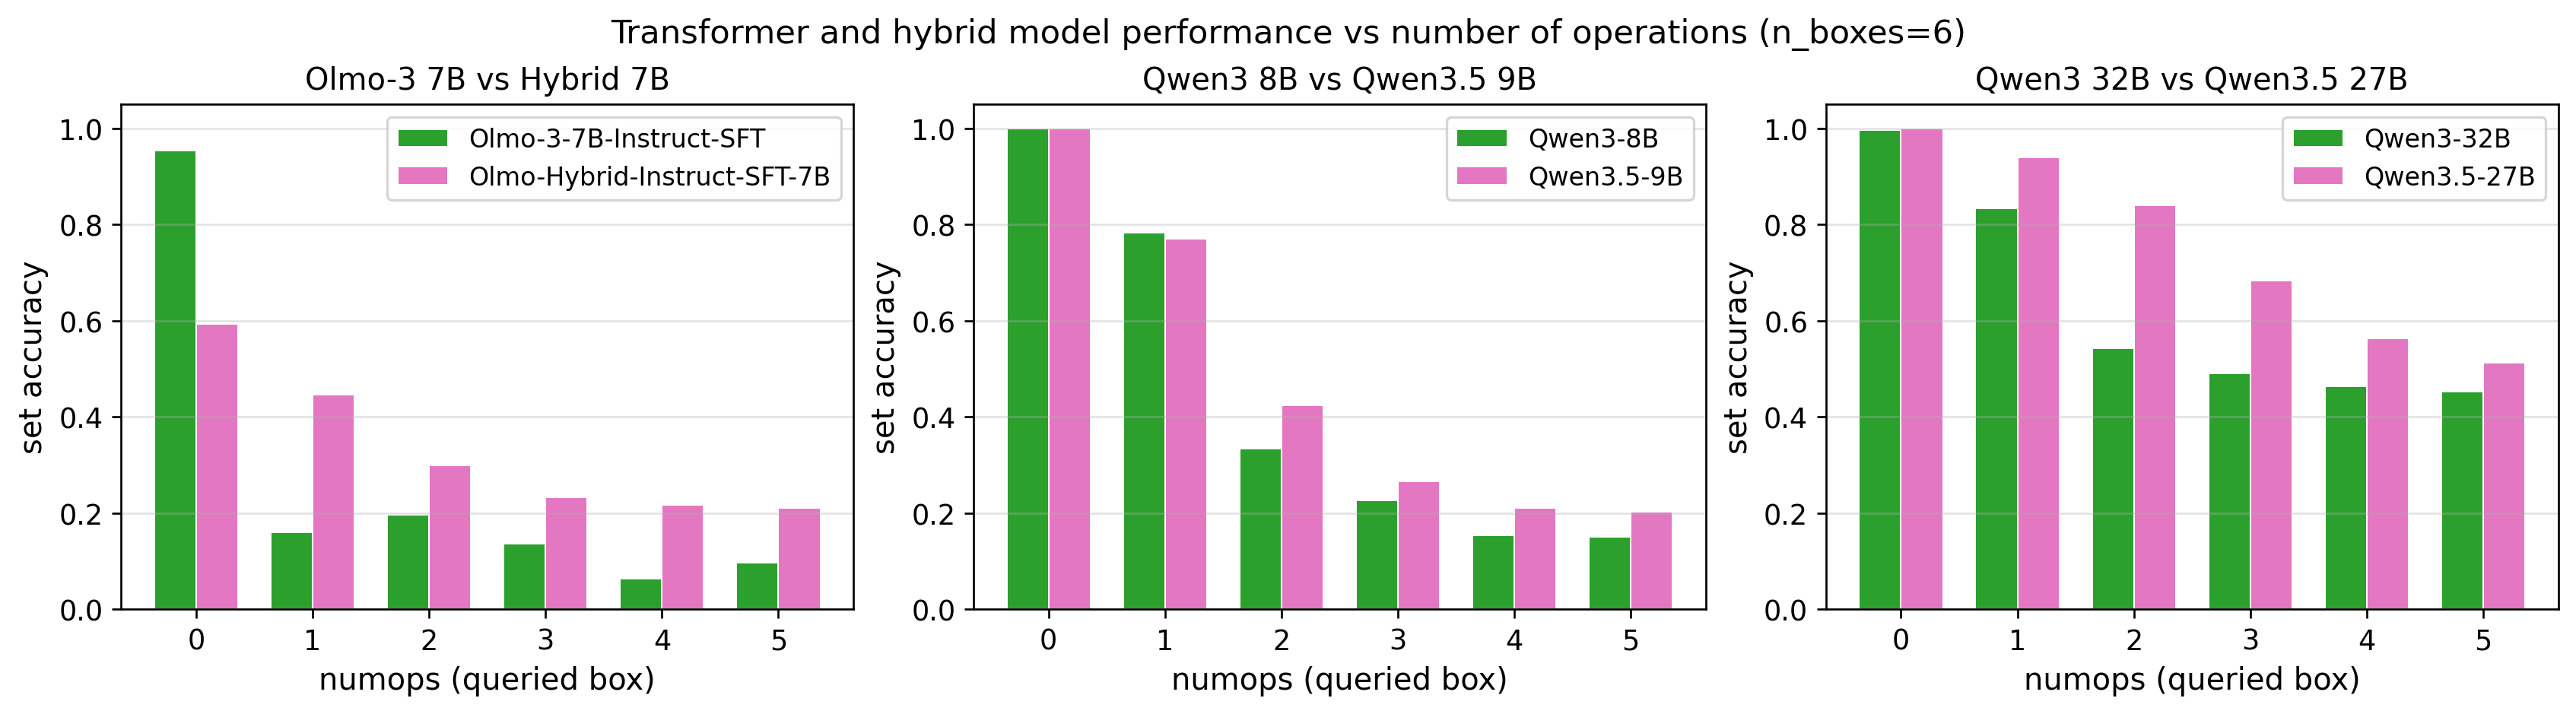

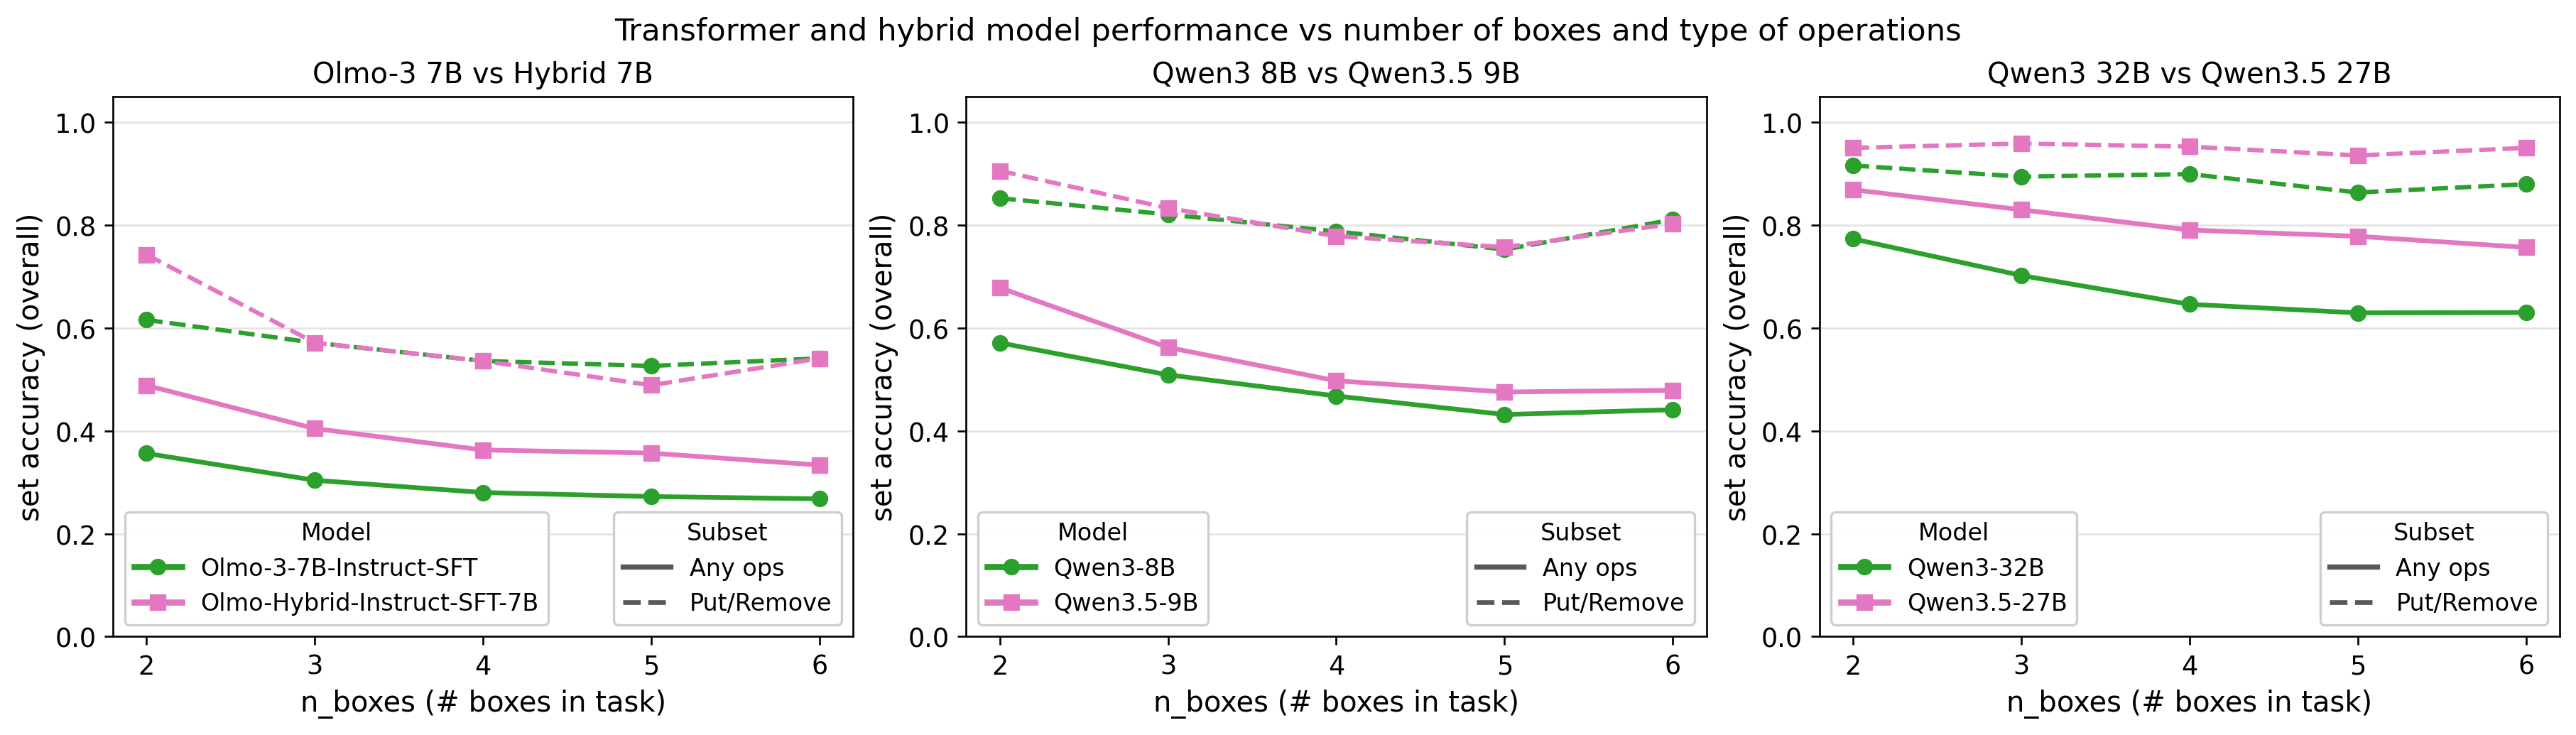

task_root: /oscar/data/epavlick/thua5/dol_interp/Tasks/State-Tracking/entity-tracking-lms


In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Add ``src/`` so ``visualize_helpers`` imports when the cwd is ``entity-tracking-lms/`` (or one level up).
for _base in (Path.cwd(), Path.cwd().parent):
    _vh = _base / "src" / "visualize_helpers.py"
    if _vh.is_file():
        sys.path.insert(0, str(_vh.parent))
        break
else:
    raise ImportError(
        "Could not find src/visualize_helpers.py; run the notebook with cwd set to "
        "entity-tracking-lms/ (or the repo folder that contains src/)."
    )

from visualize_helpers import (
    DEFAULT_COMPARISON_TRIPLETS,
    DEFAULT_N_BOXES_RANGE,
    NUMOPS_BINS,
    plot_model_family_comparison_figure,
    plot_n_boxes_numops_trend_figure,
    task_root,
)

# Bar chart at a single n_boxes
fig1, axes1 = plot_model_family_comparison_figure(n_boxes=6, op_types="any", suptitle="Transformer and hybrid model performance vs number of operations (n_boxes=6)")
plt.show()

# Lines: mean of pair vs n_boxes in DEFAULT_N_BOXES_RANGE (2..6)
fig2, axes2 = plot_n_boxes_numops_trend_figure(op_types="any", suptitle="Transformer and hybrid model performance vs number of boxes and type of operations")
plt.show()

print("task_root:", task_root())

